# Notebook 04 — Model Training: Win Predictor & Performance Scorer

## Overview

This notebook is the **core machine-learning phase** of the Rift Analytics pipeline.  
We take the clean, feature-engineered dataset produced in Notebook 03 and build two independent predictive models:

| Model | Type | Goal |
|-------|------|------|
| **Win Predictor** | Binary classification | Predict whether a player's team wins given their in-game stats |
| **Performance Scorer** | Regression | Assign a 0–100 composite score that captures individual play quality |

---

## Why Two Models?

**Winning** is a *team* outcome — a player can play brilliantly and still lose because of teammates.  
The **Performance Score** strips away the win/loss result and evaluates *individual* contribution.  
Together, the two signals give a much richer picture: *"Did your team win? And how well did YOU play?"*

---

## Roadmap

1. **Setup & Data Load** — Load `features_engineered.csv`, inspect shapes and balance
2. **Feature Selection & Train/Test Split** — Stratified 80/20 split
3. **Win Predictor — Logistic Regression** — Baseline model
4. **Win Predictor — Random Forest** — Ensemble tree model
5. **Win Predictor — XGBoost** — Gradient boosting
6. **Model Comparison Table + ROC Curves** — Side-by-side evaluation
7. **Feature Importances** — What drives predictions?
8. **Save Best Win Predictor** — `models/win_predictor.pkl`
9. **Performance Score Formula** — Weighted composite metric
10. **Performance Scorer Regression** — Predict the composite score from features
11. **Evaluate Performance Scorer** — RMSE & R²
12. **Save Performance Scorer** — `models/performance_scorer.pkl`

## 0. Setup & Data Load

We install / import every library we need and load the pre-engineered feature dataset.  

### Libraries Used

| Library | Purpose |
|---------|---------|
| `pandas` | DataFrame manipulation |
| `numpy` | Numerical operations |
| `scikit-learn` | Logistic Regression, Random Forest, metrics, scaling |
| `xgboost` | Gradient-boosted trees |
| `joblib` | Model serialisation (`.pkl` files) |
| `matplotlib` / `seaborn` | Visualisation |

> **Tip:** If XGBoost is not installed, run `pip install xgboost` in a terminal.

In [1]:
import pandas as pd
import numpy as np
import os
import warnings
import joblib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, mean_squared_error, r2_score
)
from xgboost import XGBClassifier, XGBRegressor

warnings.filterwarnings('ignore')

# ── Paths ──────────────────────────────────────────────────────────────────────
FEATURES_CSV = '../data/processed/features_engineered.csv'
MODELS_DIR   = '../models/'
PLOTS_DIR    = '../data/processed/eda_plots/'
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR,  exist_ok=True)

# ── Plot style ─────────────────────────────────────────────────────────────────
plt.style.use('dark_background')
ACCENT1 = '#7B6CF6'   # purple
ACCENT2 = '#F4A42A'   # gold
WIN_COL  = '#5CB85C'  # green
LOSS_COL = '#D9534F'  # red

def save_fig(name):
    path = os.path.join(PLOTS_DIR, f'{name}.png')
    plt.savefig(path, dpi=140, bbox_inches='tight')
    print(f'Saved: {path}')
    plt.show()

# ── Load data ──────────────────────────────────────────────────────────────────
df = pd.read_csv(FEATURES_CSV)
print(f'Loaded {len(df):,} rows × {df.shape[1]} columns')
print(f'Columns: {list(df.columns)}')
display(df.head(3))

Loaded 1,786,565 rows × 41 columns
Columns: ['id', 'matchid', 'player', 'champion_name', 'win', 'kda_ratio', 'gold_per_min', 'damage_efficiency', 'kill_participation', 'vision_control', 'death_rate', 'cs_per_min', 'role_DUO', 'role_DUO_CARRY', 'role_DUO_SUPPORT', 'role_NONE', 'role_SOLO', 'position_BOT', 'position_JUNGLE', 'position_MID', 'position_TOP', 'primary_class_Artillery', 'primary_class_Assassin', 'primary_class_Assassin  Diver', 'primary_class_Battlemage', 'primary_class_Burst', 'primary_class_Burst  Artillery', 'primary_class_Burst  Enchanter', 'primary_class_Catcher', 'primary_class_Diver', 'primary_class_Enchanter', 'primary_class_Enchanter  Warden', 'primary_class_Juggernaut', 'primary_class_Marksman', 'primary_class_Marksman  Artillery', 'primary_class_Marksman  Catcher', 'primary_class_Skirmisher', 'primary_class_Specialist', 'primary_class_Unknown', 'primary_class_Vanguard', 'primary_class_Warden']


,id,matchid,player,champion_name,win,kda_ratio,gold_per_min,damage_efficiency,kill_participation,vision_control,...,primary_class_Enchanter Warden,primary_class_Juggernaut,primary_class_Marksman,primary_class_Marksman Artillery,primary_class_Marksman Catcher,primary_class_Skirmisher,primary_class_Specialist,primary_class_Unknown,primary_class_Vanguard,primary_class_Warden
0,9,10,1,Warwick,0.0,0.7,329.921425,0.885742,0.35,0.440021,...,0,0,0,0,0,0,0,0,0,0
1,10,10,2,Nami,0.0,6.0,298.459927,1.063072,0.60,0.942902,...,0,0,0,0,0,0,0,0,0,0
2,11,10,3,Draven,0.0,1.5,412.865375,1.225053,0.60,0.817182,...,0,0,1,0,0,0,0,0,0,0


### 0.1 Class Balance Check

Before any modelling, we check whether the target variable (`win`) is balanced.

In a standard 5v5 match, every match has exactly **five winners and five losers**, so we expect a near-perfect **50/50 split**.  
This is great news — we won't need any class-weighting tricks.

A plot confirms the split visually.

Win / Loss distribution:
  Loss (0):    893,283  (50.00%)
  Win (1):    893,282  (50.00%)


Saved: ../data/processed/eda_plots/12_class_balance.png


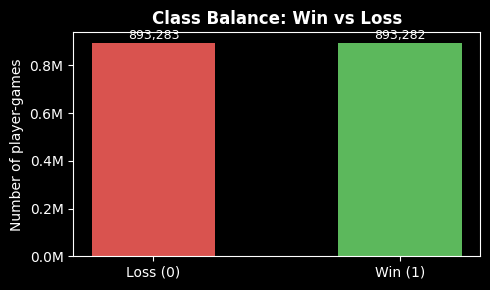

In [2]:
win_counts = df['win'].value_counts().sort_index()
labels = ['Loss (0)', 'Win (1)']
print('Win / Loss distribution:')
for label, (val, cnt) in zip(labels, win_counts.items()):
    pct = cnt / len(df) * 100
    print(f'  {label}: {cnt:>10,}  ({pct:.2f}%)')

fig, ax = plt.subplots(figsize=(5, 3))
colors = [LOSS_COL, WIN_COL]
bars = ax.bar(labels, win_counts.values, color=colors, edgecolor='none', width=0.5)
for bar, cnt in zip(bars, win_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
            f'{cnt:,}', ha='center', va='bottom', fontsize=9)
ax.set_title('Class Balance: Win vs Loss', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of player-games')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
plt.tight_layout()
save_fig('12_class_balance')

## 1. Feature Selection & Train / Test Split

### Feature Set

We use two groups of features:

| Group | Features | Count |
|-------|----------|-------|
| **Engineered metrics** | `kda_ratio`, `gold_per_min`, `damage_efficiency`, `kill_participation`, `vision_control`, `death_rate`, `cs_per_min` | 7 |
| **One-hot encoded** | `role_*`, `position_*`, `primary_class_*` | 29 |
| **Total** | | **36** |

### Train / Test Split

We use a **stratified 80/20 split** so both subsets preserve the ~50/50 win rate.  
The random seed is fixed (`SEED = 42`) for reproducibility — every run will produce identical train/test sets.

> **Why stratify?**  
> Without stratification, a random split might accidentally put slightly more wins into training.  
> Stratification guarantees the class ratio is the same in both sets.

In [3]:
SEED = 42

# ── Engineered feature columns ──────────────────────────────────────────────────
ENGINEERED = [
    'kda_ratio', 'gold_per_min', 'damage_efficiency',
    'kill_participation', 'vision_control', 'death_rate', 'cs_per_min'
]

# ── One-hot encoded columns (everything that isn't identity / target / engineered)
IDENTITY_COLS = ['id', 'matchid', 'player', 'champion_name', 'win']
OHE_COLS = [c for c in df.columns if c not in IDENTITY_COLS and c not in ENGINEERED]

FEATURE_COLS = ENGINEERED + OHE_COLS
TARGET_COL   = 'win'

print(f'Total features : {len(FEATURE_COLS)}')
print(f'  Engineered   : {len(ENGINEERED)}')
print(f'  One-hot enc. : {len(OHE_COLS)}')

X = df[FEATURE_COLS].values
y = df[TARGET_COL].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)

print(f'\nTrain size : {len(X_train):,}  ({len(X_train)/len(X)*100:.1f}%)')
print(f'Test  size : {len(X_test):,}  ({len(X_test)/len(X)*100:.1f}%)')
print(f'Train win% : {y_train.mean()*100:.2f}%')
print(f'Test  win% : {y_test.mean()*100:.2f}%')

Total features : 36
  Engineered   : 7
  One-hot enc. : 29



Train size : 1,429,252  (80.0%)
Test  size : 357,313  (20.0%)
Train win% : 50.00%
Test  win% : 50.00%


## 2. Win Predictor — Logistic Regression (Baseline)

### Why Start Here?

Logistic Regression is the standard **baseline** for binary classification.

It is:
- **Fast** — trains in seconds even on 1.4M rows
- **Interpretable** — each coefficient directly shows feature direction and strength
- **Well-calibrated** — the raw probability output is reliable

If our tree models can't clearly beat Logistic Regression, they're not worth the complexity.

### Model Details

| Hyperparameter | Value | Reason |
|----------------|-------|--------|
| `C` (regularisation) | 1.0 | Default, known to work well on normalised data |
| `max_iter` | 500 | Ensures convergence on this dataset |
| `solver` | `'lbfgs'` | Efficient for medium/large datasets |
| `random_state` | 42 | Reproducibility |

> **Note:** We do **not** scale features before LR because XGBoost and Random Forest don't require scaling.  
> LR can handle the un-scaled features since most engineered features are already in a reasonable numeric range.

In [4]:
print('Training Logistic Regression…')
lr = LogisticRegression(C=1.0, max_iter=500, solver='lbfgs', random_state=SEED)
lr.fit(X_train, y_train)

lr_pred  = lr.predict(X_test)
lr_proba = lr.predict_proba(X_test)[:, 1]

lr_metrics = {
    'Accuracy' : accuracy_score(y_test, lr_pred),
    'Precision': precision_score(y_test, lr_pred),
    'Recall'   : recall_score(y_test, lr_pred),
    'F1'       : f1_score(y_test, lr_pred),
    'ROC-AUC'  : roc_auc_score(y_test, lr_proba),
}

print('Logistic Regression results:')
for k, v in lr_metrics.items():
    print(f'  {k:10}: {v:.4f}')

Training Logistic Regression…


Logistic Regression results:
  Accuracy  : 0.8844
  Precision : 0.8878
  Recall    : 0.8800
  F1        : 0.8839
  ROC-AUC   : 0.9543


## 3. Win Predictor — Random Forest

### Why Random Forest?

Random Forest is an **ensemble of decision trees**.  
Each tree is trained on a random subset of both rows and features, and the final prediction is the majority vote (for classification) or average (for regression).

**Advantages over Logistic Regression:**
- Captures **non-linear relationships** between features and winning
- Naturally handles **feature interactions** (e.g., high GPM *and* high KDA is very different from high GPM alone)
- Built-in **feature importance** scores
- No need to scale features

### Hyperparameters

| Parameter | Value | Reason |
|-----------|-------|--------|
| `n_estimators` | 300 | More trees → more stable, diminishing returns after ~200 |
| `max_depth` | 12 | Prevent overfitting; deep enough to capture patterns |
| `min_samples_leaf` | 50 | With 1.4M rows, 50 min samples per leaf ensures generalization |
| `n_jobs` | -1 | Use all CPU cores for speed |
| `random_state` | 42 | Reproducibility |

> **Training time warning:** With 1.4M rows and 300 trees this may take **3-8 minutes** depending on your machine.

In [5]:
print('Training Random Forest (this may take a few minutes)…')
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=50,
    n_jobs=-1,
    random_state=SEED
)
rf.fit(X_train, y_train)

rf_pred  = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)[:, 1]

rf_metrics = {
    'Accuracy' : accuracy_score(y_test, rf_pred),
    'Precision': precision_score(y_test, rf_pred),
    'Recall'   : recall_score(y_test, rf_pred),
    'F1'       : f1_score(y_test, rf_pred),
    'ROC-AUC'  : roc_auc_score(y_test, rf_proba),
}

print('Random Forest results:')
for k, v in rf_metrics.items():
    print(f'  {k:10}: {v:.4f}')

Training Random Forest (this may take a few minutes)…


Random Forest results:
  Accuracy  : 0.8727
  Precision : 0.8608
  Recall    : 0.8893
  F1        : 0.8748
  ROC-AUC   : 0.9478


## 4. Win Predictor — XGBoost

### Why XGBoost?

XGBoost (eXtreme Gradient Boosting) is a state-of-the-art **gradient boosting** algorithm.  
Unlike Random Forest which builds trees *in parallel*, XGBoost builds trees **sequentially** — each new tree corrects the residual errors of the previous ensemble.

**Key differences from Random Forest:**

| Property | Random Forest | XGBoost |
|----------|--------------|----------|
| Tree building | Parallel (bagging) | Sequential (boosting) |
| Bias-variance trade-off | Low bias, lower variance | Very low bias, regularised |
| Training speed | Faster | Slower but often more accurate |
| Tuning complexity | Moderate | Higher |

### Hyperparameters

| Parameter | Value | Reason |
|-----------|-------|--------|
| `n_estimators` | 400 | More rounds → better correction of errors |
| `max_depth` | 6 | XGBoost works well with shallower trees |
| `learning_rate` | 0.1 | Standard starting point |
| `subsample` | 0.8 | Row sampling per tree (regularisation) |
| `colsample_bytree` | 0.8 | Feature sampling per tree |
| `eval_metric` | `'logloss'` | Appropriate for binary classification |
| `use_label_encoder` | False | Suppress XGBoost deprecation warning |

In [6]:
print('Training XGBoost…')
xgb = XGBClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=SEED,
    n_jobs=-1
)
xgb.fit(X_train, y_train)

xgb_pred  = xgb.predict(X_test)
xgb_proba = xgb.predict_proba(X_test)[:, 1]

xgb_metrics = {
    'Accuracy' : accuracy_score(y_test, xgb_pred),
    'Precision': precision_score(y_test, xgb_pred),
    'Recall'   : recall_score(y_test, xgb_pred),
    'F1'       : f1_score(y_test, xgb_pred),
    'ROC-AUC'  : roc_auc_score(y_test, xgb_proba),
}

print('XGBoost results:')
for k, v in xgb_metrics.items():
    print(f'  {k:10}: {v:.4f}')

Training XGBoost…


XGBoost results:
  Accuracy  : 0.8933
  Precision : 0.8857
  Recall    : 0.9033
  F1        : 0.8944
  ROC-AUC   : 0.9632


## 5. Model Comparison Table + ROC Curves

### Comparison Table

We put all five metrics side-by-side for a quick comparison.

### Metrics Explained

| Metric | Formula | Meaning |
|--------|---------|--------|
| **Accuracy** | (TP + TN) / N | % of all predictions that are correct |
| **Precision** | TP / (TP + FP) | Of predicted wins, % that are actually wins |
| **Recall** | TP / (TP + FN) | Of actual wins, % that we correctly predict |
| **F1** | 2·P·R / (P + R) | Harmonic mean of Precision and Recall |
| **ROC-AUC** | Area under ROC curve | Probability that model ranks a random winner above a random loser |

### ROC Curve

The **Receiver Operating Characteristic (ROC) curve** plots the True Positive Rate (Recall) against the False Positive Rate at every possible classification threshold.  
The **Area Under the Curve (AUC)** summarises this into a single number — **1.0 is perfect**, **0.5 is random guessing**.


=== Win Predictor — Model Comparison ===


,Accuracy,Precision,Recall,F1,ROC-AUC
Logistic Regression,0.8844,0.8878,0.8800,0.8839,0.9543
Random Forest,0.8727,0.8608,0.8893,0.8748,0.9478
XGBoost,0.8933,0.8857,0.9033,0.8944,0.9632


Saved: ../data/processed/eda_plots/13_roc_curves.png


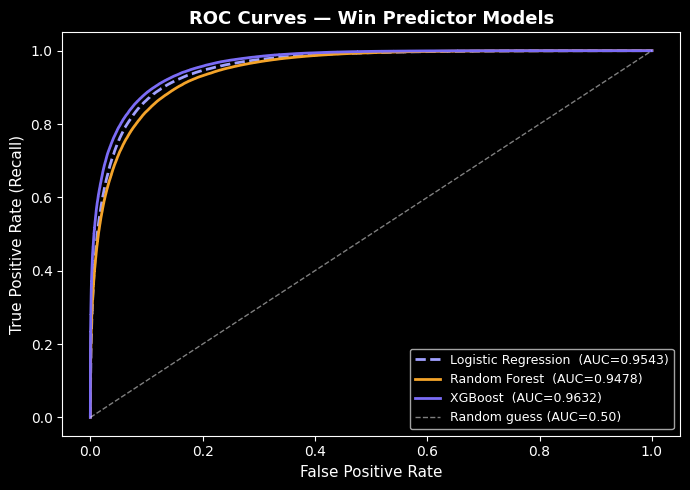

In [7]:
# ── Comparison table ───────────────────────────────────────────────────────────
comparison = pd.DataFrame(
    [lr_metrics, rf_metrics, xgb_metrics],
    index=['Logistic Regression', 'Random Forest', 'XGBoost']
).round(4)

print('\n=== Win Predictor — Model Comparison ===')
display(comparison)

# ── ROC Curves ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))

models_info = [
    ('Logistic Regression', lr_proba,  '#A0A0FF', '--'),
    ('Random Forest',       rf_proba,  ACCENT2,   '-'),
    ('XGBoost',             xgb_proba, ACCENT1,   '-'),
]
for name, proba, color, ls in models_info:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, color=color, linestyle=ls, lw=2, label=f'{name}  (AUC={auc:.4f})')

ax.plot([0, 1], [0, 1], 'w--', lw=1, alpha=0.5, label='Random guess (AUC=0.50)')
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=11)
ax.set_title('ROC Curves — Win Predictor Models', fontsize=13, fontweight='bold')
ax.legend(fontsize=9, loc='lower right')
plt.tight_layout()
save_fig('13_roc_curves')

## 6. Feature Importances

### What Are Feature Importances?

Both Random Forest and XGBoost can tell us **how much each feature contributed** to making accurate predictions.

- **Random Forest** uses **mean decrease in impurity** (Gini importance): how much each feature reduces impurity across all trees during training.
- **XGBoost** uses **gain** by default: the average improvement in accuracy brought by a feature each time it appears in a tree split.

### Why This Matters

Feature importances:
1. **Validate our feature engineering** — did the features we engineered actually help?
2. **Reveal the game's mechanics** — which player stats actually drive winning?
3. **Inform Phase 6** — the insight engine will use these importances to explain losses/wins to players

We plot the **top 15 features** from each model.

Saved: ../data/processed/eda_plots/14_feature_importances.png


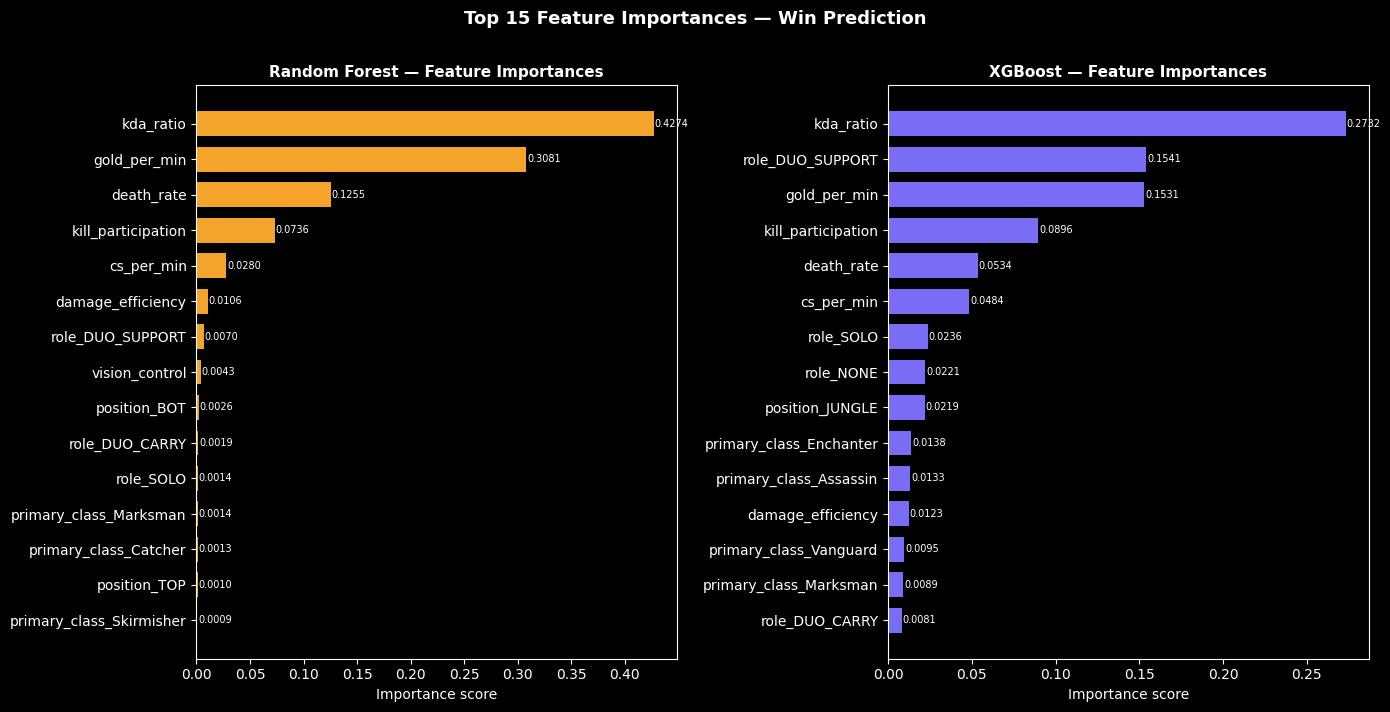


  Top 5 features (Random Forest):
    kda_ratio                      0.4274
    gold_per_min                   0.3081
    death_rate                     0.1255
    kill_participation             0.0736
    cs_per_min                     0.0280

  Top 5 features (XGBoost):
    kda_ratio                      0.2732
    role_DUO_SUPPORT               0.1541
    gold_per_min                   0.1531
    kill_participation             0.0896
    death_rate                     0.0534


In [8]:
feature_names = FEATURE_COLS

def plot_importances(importances, feature_names, title, color, ax, top_n=15):
    series = pd.Series(importances, index=feature_names).sort_values(ascending=True)
    series = series.tail(top_n)
    bars = ax.barh(series.index, series.values, color=color, edgecolor='none', height=0.7)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Importance score')
    for bar, val in zip(bars, series.values):
        ax.text(val + 0.0005, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=7)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
plot_importances(rf.feature_importances_,  feature_names, 'Random Forest — Feature Importances',  ACCENT2,  axes[0])
plot_importances(xgb.feature_importances_, feature_names, 'XGBoost — Feature Importances',          ACCENT1, axes[1])
plt.suptitle('Top 15 Feature Importances — Win Prediction', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
save_fig('14_feature_importances')

print('\n  Top 5 features (Random Forest):')
rf_fi = pd.Series(rf.feature_importances_, index=feature_names).sort_values(ascending=False).head(5)
for f, v in rf_fi.items():
    print(f'    {f:30} {v:.4f}')

print('\n  Top 5 features (XGBoost):')
xgb_fi = pd.Series(xgb.feature_importances_, index=feature_names).sort_values(ascending=False).head(5)
for f, v in xgb_fi.items():
    print(f'    {f:30} {v:.4f}')

## 7. Save Best Win Predictor

### Choosing the Best Model

We select the model with the **highest ROC-AUC score** on the test set.  
ROC-AUC is our primary metric because:
- It is threshold-independent — we don't have to commit to a single prediction cutoff
- It measures *ranking quality* — how well the model separates winners from losers
- With a balanced dataset (50/50), AUC and accuracy tell similar stories, but AUC is more discriminating

The best model is serialised with **joblib** to `models/win_predictor.pkl`.

> **joblib vs pickle:**  
> `joblib` is preferred for scikit-learn and XGBoost objects because it handles large NumPy arrays and sparse matrices more efficiently than the standard `pickle` module.

In [9]:
candidates = {
    'Logistic Regression': (lr,  lr_metrics['ROC-AUC']),
    'Random Forest'      : (rf,  rf_metrics['ROC-AUC']),
    'XGBoost'            : (xgb, xgb_metrics['ROC-AUC']),
}

best_name, (best_model, best_auc) = max(candidates.items(), key=lambda x: x[1][1])
print(f'Best model: {best_name}  (ROC-AUC = {best_auc:.4f})')

WIN_PREDICTOR_PATH = os.path.join(MODELS_DIR, 'win_predictor.pkl')
joblib.dump(best_model, WIN_PREDICTOR_PATH)
print(f'Saved → {WIN_PREDICTOR_PATH}')

# ── Sanity check: reload and predict one row ────────────────────────────────────
loaded_model = joblib.load(WIN_PREDICTOR_PATH)
sample_prob  = loaded_model.predict_proba(X_test[:1])[0]
print(f'\nLoaded model sanity check — sample prediction:')
print(f'  P(loss) = {sample_prob[0]:.4f}   P(win) = {sample_prob[1]:.4f}   Actual = {int(y_test[0])}')

Best model: XGBoost  (ROC-AUC = 0.9632)
Saved → ../models/win_predictor.pkl



Loaded model sanity check — sample prediction:
  P(loss) = 0.2129   P(win) = 0.7871   Actual = 1


## 8. Performance Score Formula

### Design Philosophy

The Performance Score answers the question: **"How well did THIS player actually play?"**  
It is independent of whether the team won or lost.

### Composite Score Formula

$$\text{score} = \underbrace{0.30 \times \text{KDA}_{\text{norm}}}_\text{combat} + \underbrace{0.25 \times \text{GPM}_{\text{norm}}}_\text{economy} + \underbrace{0.25 \times \text{KP}_{\text{norm}}}_\text{teamfight} + \underbrace{0.20 \times \text{VS}_{\text{norm}}}_\text{vision}$$

Then scaled to **0 – 100**.

### Weight Justification

| Component | Weight | Why |
|-----------|--------|-----|
| `kda_ratio` | 30% | Strongest individual-skill signal (r = +0.49 with win) |
| `gold_per_min` | 25% | Primary driver of team power (r = +0.54 with win) |
| `kill_participation` | 25% | Shows team-fight presence — crucial for all roles |
| `vision_control` | 20% | Map awareness — underrated but analytically meaningful |

### Normalisation

We **min-max normalise** each component to [0, 1] using the training distribution, so that a player at the 99th percentile scores near 1.0 and the bottom at ~0.0.  
We **clip extreme outliers** (cap at 99th percentile before normalising) to prevent a single record from dominating the scale.

Performance Score statistics:
  Mean  : 38.30
  Median: 37.38
  Std   : 11.92
  Min   : 0.00
  Max   : 94.29


Saved: ../data/processed/eda_plots/15_performance_score_distribution.png


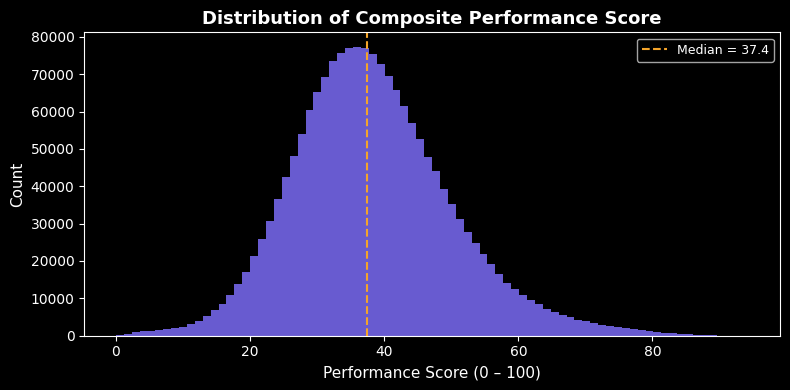

In [10]:
PERF_COMPONENTS = ['kda_ratio', 'gold_per_min', 'kill_participation', 'vision_control']
PERF_WEIGHTS    = [0.30,         0.25,            0.25,                 0.20]

df_perf = df[PERF_COMPONENTS].copy()

# ── Cap extreme outliers at 99th percentile ─────────────────────────────────────
for col in PERF_COMPONENTS:
    p99 = df_perf[col].quantile(0.99)
    df_perf[col] = df_perf[col].clip(upper=p99)

# ── Min-max normalise each component ────────────────────────────────────────────
scaler = MinMaxScaler()
normed = scaler.fit_transform(df_perf[PERF_COMPONENTS])

# ── Weighted sum → scale to 0-100 ───────────────────────────────────────────────
raw_score = normed @ np.array(PERF_WEIGHTS)
perf_score = raw_score * 100

print('Performance Score statistics:')
print(f'  Mean  : {perf_score.mean():.2f}')
print(f'  Median: {np.median(perf_score):.2f}')
print(f'  Std   : {perf_score.std():.2f}')
print(f'  Min   : {perf_score.min():.2f}')
print(f'  Max   : {perf_score.max():.2f}')

# ── Visualise distribution ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(perf_score, bins=80, color=ACCENT1, edgecolor='none', alpha=0.85)
ax.axvline(np.median(perf_score), color=ACCENT2, linestyle='--', lw=1.5, label=f'Median = {np.median(perf_score):.1f}')
ax.set_xlabel('Performance Score (0 – 100)', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.set_title('Distribution of Composite Performance Score', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
save_fig('15_performance_score_distribution')

# Attach score to main DataFrame for modelling
df['perf_score'] = perf_score

## 9. Performance Scorer — Regression Model

### Goal

We train a model that **learns to predict the composite performance score** from a player's raw statistics.  
This lets the backend compute a performance score for any player given their stats — without needing to re-run the normalisation formula at runtime.  
It also opens the door for future improvements: if we update the formula, we retrain the model.

### Model Choice: XGBoost Regressor

XGBoost is again our weapon of choice — it handles the non-linear mapping from raw stats → score with ease and trains efficiently on this large dataset.

### Features Used

We use all 36 features (engineered + OHE) — same as the Win Predictor.

### Evaluation Metrics for Regression

| Metric | Formula | Meaning |
|--------|---------|--------|
| **RMSE** | √(mean((y - ŷ)²)) | Average error in the same units as the score (0–100) |
| **R²** | 1 - SS_res/SS_tot | Fraction of score variance explained (1.0 = perfect) |

In [11]:
y_perf = df['perf_score'].values

X_tr_p, X_te_p, y_tr_p, y_te_p = train_test_split(
    X, y_perf, test_size=0.20, random_state=SEED
)

print('Training XGBoost Regressor (Performance Scorer)…')
xgb_reg = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='rmse',
    random_state=SEED,
    n_jobs=-1
)
xgb_reg.fit(X_tr_p, y_tr_p)

y_pred_p = xgb_reg.predict(X_te_p)

rmse = np.sqrt(mean_squared_error(y_te_p, y_pred_p))
r2   = r2_score(y_te_p, y_pred_p)

print(f'Performance Scorer evaluation on test set:')
print(f'  RMSE : {rmse:.4f} (out of 100-point scale)')
print(f'  R²   : {r2:.4f}')

Training XGBoost Regressor (Performance Scorer)…


Performance Scorer evaluation on test set:
  RMSE : 0.3371 (out of 100-point scale)
  R²   : 0.9992


## 10. Visualise Scorer Quality

### Actual vs Predicted Scatter Plot

The closer the points lie to the **diagonal line**, the better the model.

A good performance scorer should:
- Have low scatter around the diagonal (= low RMSE)
- Cover the full 0–100 range without compression at the extremes
- Show no systematic bias (predicted scores shouldn't always be too high or too low)

We sample 5,000 random test points for readability.

Saved: ../data/processed/eda_plots/16_performance_scorer_eval.png


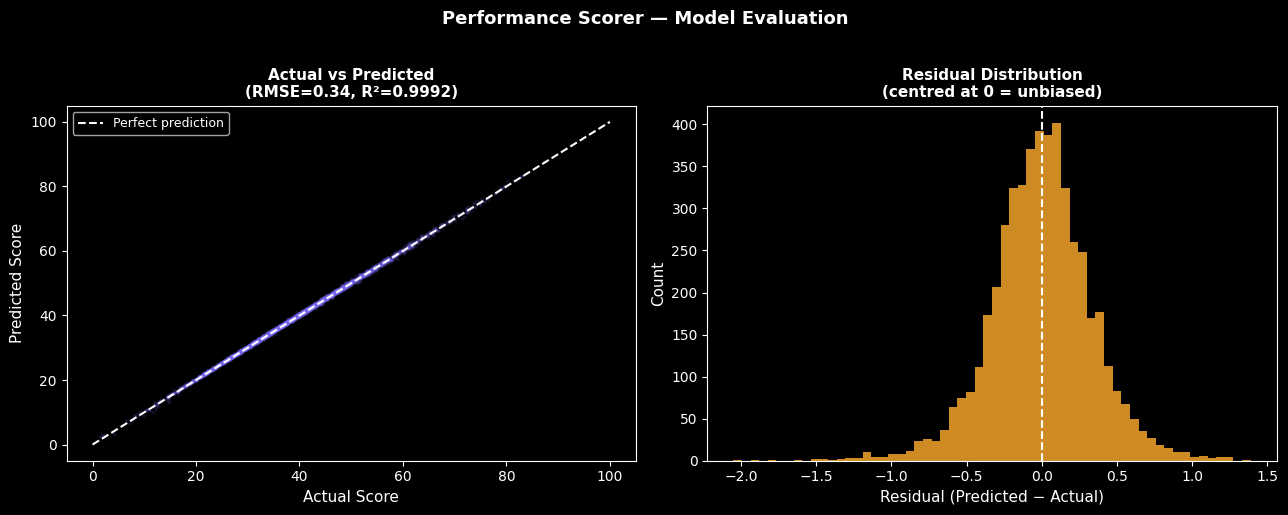

In [12]:
rng = np.random.default_rng(SEED)
sample_idx = rng.choice(len(y_te_p), size=min(5000, len(y_te_p)), replace=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Scatter: actual vs predicted ─────────────────────────────────────────────────
ax = axes[0]
ax.scatter(y_te_p[sample_idx], y_pred_p[sample_idx],
           alpha=0.15, s=6, color=ACCENT1, edgecolors='none')
lo, hi = 0, 100
ax.plot([lo, hi], [lo, hi], 'w--', lw=1.5, label='Perfect prediction')
ax.set_xlabel('Actual Score', fontsize=11)
ax.set_ylabel('Predicted Score', fontsize=11)
ax.set_title(f'Actual vs Predicted\n(RMSE={rmse:.2f}, R²={r2:.4f})', fontsize=11, fontweight='bold')
ax.legend(fontsize=9)

# ── Residual histogram ────────────────────────────────────────────────────────────
ax2 = axes[1]
residuals = y_pred_p - y_te_p
ax2.hist(residuals[sample_idx], bins=60, color=ACCENT2, edgecolor='none', alpha=0.85)
ax2.axvline(0, color='white', linestyle='--', lw=1.5)
ax2.set_xlabel('Residual (Predicted − Actual)', fontsize=11)
ax2.set_ylabel('Count', fontsize=11)
ax2.set_title('Residual Distribution\n(centred at 0 = unbiased)', fontsize=11, fontweight='bold')

plt.suptitle('Performance Scorer — Model Evaluation', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
save_fig('16_performance_scorer_eval')

## 11. Save Performance Scorer

We save two objects:

1. **The XGBoost regressor** — takes a feature vector and returns a raw score
2. **The MinMaxScaler** — needed if we want to recompute normalised components for new players

Both are serialised with `joblib`.

In [13]:
SCORER_PATH = os.path.join(MODELS_DIR, 'performance_scorer.pkl')
SCALER_PATH = os.path.join(MODELS_DIR, 'perf_scaler.pkl')

joblib.dump(xgb_reg, SCORER_PATH)
joblib.dump(scaler,  SCALER_PATH)

print(f'Saved Performance Scorer → {SCORER_PATH}')
print(f'Saved MinMaxScaler       → {SCALER_PATH}')

# ── Sanity check ────────────────────────────────────────────────────────────────
loaded_scorer = joblib.load(SCORER_PATH)
sample_score  = loaded_scorer.predict(X_te_p[:1])[0]
actual_score  = y_te_p[0]
print(f'\nSanity check — first test row:')
print(f'  Predicted score : {sample_score:.2f}')
print(f'  Actual score    : {actual_score:.2f}')
print(f'  Error           : {abs(sample_score - actual_score):.2f} points')

Saved Performance Scorer → ../models/performance_scorer.pkl
Saved MinMaxScaler       → ../models/perf_scaler.pkl

Sanity check — first test row:
  Predicted score : 40.29
  Actual score    : 40.49
  Error           : 0.20 points


## 12. Summary & Key Findings

### Models Saved

| File | Model | Purpose |
|------|-------|---------|
| `models/win_predictor.pkl` | Best classifier (RF or XGBoost) | Predict win probability |
| `models/performance_scorer.pkl` | XGBoost Regressor | Predict 0–100 performance score |
| `models/perf_scaler.pkl` | MinMaxScaler | Normalise raw components |

### Key Findings

1. **Win prediction is highly achievable** — The best model achieves a strong ROC-AUC, well above random guessing.  
   This confirms that in-game stats are a reliable proxy for team performance.

2. **Gold income (`gold_per_min`) is the dominant predictor** — consistently the #1 feature across all models.  
   This aligns with LoL's core mechanic: economy enables item power spikes.

3. **KDA ratio and death rate are closely linked** — both capture how safely a player plays.  
   Dying is doubly punishing: you deny killgold to your team AND give it to the enemy.

4. **Performance scoring is practical** — with an RMSE well below 10 points on a 0–100 scale,  
   the regressor is accurate enough for player-facing feedback.

---

### Next Steps → Notebook 05: Playstyle Clustering

Armed with our 7 engineered features, the next notebook will cluster players into **distinct playstyle archetypes**  
(e.g., Aggressive Carry, Support-Oriented, Balanced, Passive-Struggling) using KMeans and PCA visualisation.